# Roteamento com Dijkstra — Grafo de Redes

Objetivo do trabalho: gerar o grafo da rede, aplicar o algoritmo de Dijkstra e responder:

> Qual é o caminho mais curto entre dois vértices quaisquer com o maior custo no grafo e quanto é o custo?



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

# Para reprodutibilidade
np.random.seed(0)


## 1. Geração do grafo

O grafo representa uma rede de comunicação com 100 nós posicionados aleatoriamente em uma área quadrada. Dois nós possuem enlace direto quando a distância euclidiana entre eles é menor ou igual ao alcance máximo `R`.

No script original, os custos dos enlaces são aleatórios entre 0 e 1. Como o custo é sorteado dentro do laço `k, j`, o grafo é tratado como **direcionado em custo**: pode existir enlace de `k` para `j` e de `j` para `k`, mas os custos podem ser diferentes.


In [11]:
# Parâmetros
num_nos = 100
L = 1000   # lado da área onde estão os nós
R = 200    # alcance máximo direto de um nó até seus vizinhos

# Posições dos nós
posX = np.random.rand(num_nos) * L
posY = np.random.rand(num_nos) * L

# Matrizes de conectividade e custo
matriz = np.zeros((num_nos, num_nos), dtype=int)
custo = np.full((num_nos, num_nos), np.inf)

for k in range(num_nos):
    for j in range(num_nos):
        distancia_euclidiana = np.sqrt((posX[k] - posX[j])**2 + (posY[k] - posY[j])**2)
        if distancia_euclidiana <= R:
            matriz[k, j] = 1
            custo[k, j] = np.random.rand()
        else:
            matriz[k, j] = 0
            custo[k, j] = np.inf

# Remove autoenlaces para a análise de caminhos entre vértices diferentes
np.fill_diagonal(matriz, 0)
np.fill_diagonal(custo, np.inf)

print(f"Número de nós: {num_nos}")
print(f"Número de enlaces direcionados: {matriz.sum()}")


Número de nós: 100
Número de enlaces direcionados: 992


## 2. Grafo gerado

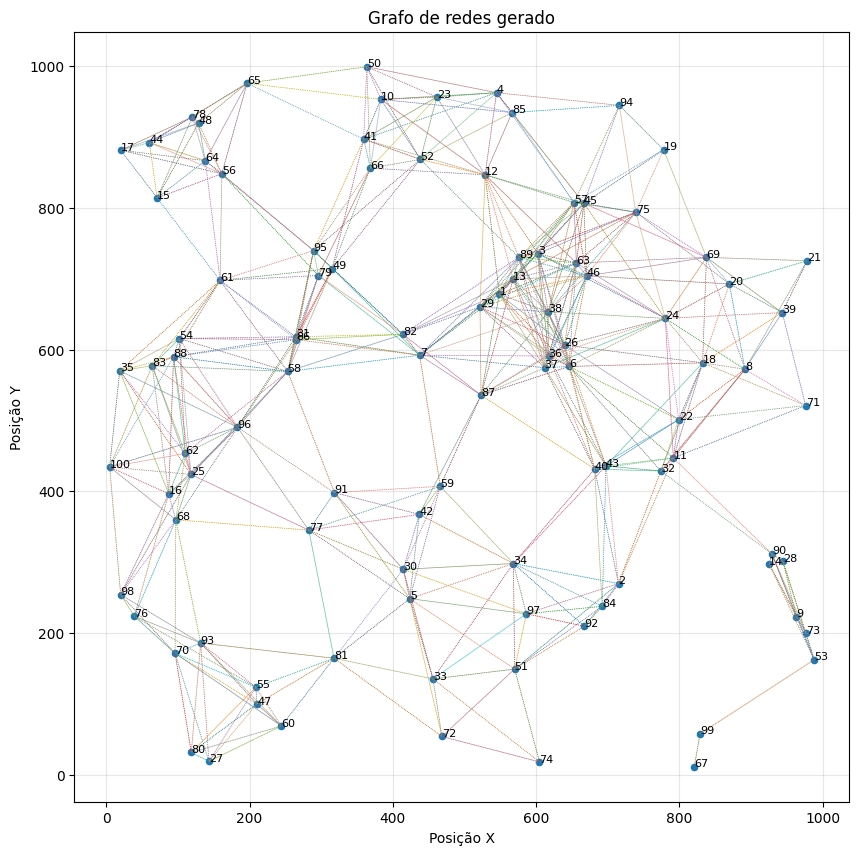

In [12]:
plt.figure(figsize=(10, 10))

# Desenha os enlaces
for k in range(num_nos):
    for j in range(num_nos):
        if matriz[k, j] == 1:
            plt.plot([posX[k], posX[j]], [posY[k], posY[j]], linestyle=':', linewidth=0.5)

# Desenha os nós
plt.scatter(posX, posY, s=20)
for k in range(num_nos):
    plt.text(posX[k], posY[k], str(k + 1), fontsize=8)

plt.title('Grafo de redes gerado')
plt.xlabel('Posição X')
plt.ylabel('Posição Y')
plt.grid(True, alpha=0.3)
plt.show()


## 3. Implementação do algoritmo de Dijkstra


In [13]:
def dijkstra(custo, origem):
    """Calcula as menores distâncias da origem até todos os vértices."""
    n = custo.shape[0]
    distancias = np.full(n, np.inf)
    precedentes = np.full(n, -1, dtype=int)
    visitado = np.zeros(n, dtype=bool)

    distancias[origem] = 0.0
    fila = [(0.0, origem)]

    while fila:
        dist_u, u = heapq.heappop(fila)

        if visitado[u]:
            continue
        visitado[u] = True

        vizinhos = np.where(np.isfinite(custo[u]))[0]
        for v in vizinhos:
            if visitado[v]:
                continue

            nova_distancia = dist_u + custo[u, v]
            if nova_distancia < distancias[v]:
                distancias[v] = nova_distancia
                precedentes[v] = u
                heapq.heappush(fila, (nova_distancia, v))

    return distancias, precedentes


def reconstruir_caminho(precedentes, origem, destino):
    """Reconstrói o caminho mínimo da origem ao destino usando o vetor de precedentes."""
    caminho = []
    atual = destino

    while atual != -1:
        caminho.append(atual)
        if atual == origem:
            break
        atual = precedentes[atual]

    if caminho[-1] != origem:
        return []

    caminho.reverse()
    return caminho


## 4. Busca do menor caminho com maior custo entre todos os pares
1. Executar Dijkstra usando cada nó como origem.
2. Guardar os menores caminhos para todos os destinos alcançáveis.
3. Selecionar o par origem-destino cujo menor caminho possui o maior custo total.


In [14]:
maior_custo = -np.inf
melhor_origem = None
melhor_destino = None
melhor_precedentes = None
melhor_distancias = None

for origem in range(num_nos):
    distancias, precedentes = dijkstra(custo, origem)

    for destino in range(num_nos):
        if origem == destino:
            continue
        if np.isfinite(distancias[destino]) and distancias[destino] > maior_custo:
            maior_custo = distancias[destino]
            melhor_origem = origem
            melhor_destino = destino
            melhor_precedentes = precedentes.copy()
            melhor_distancias = distancias.copy()

melhor_caminho = reconstruir_caminho(melhor_precedentes, melhor_origem, melhor_destino)
melhor_caminho_humano = [int(v + 1) for v in melhor_caminho]

print('Resultado:')
print(f'Origem: {melhor_origem + 1}')
print(f'Destino: {melhor_destino + 1}')
print(f'Caminho mínimo com maior custo: {melhor_caminho_humano}')
print(f'Custo total: {maior_custo:.6f}')


Resultado:
Origem: 48
Destino: 67
Caminho mínimo com maior custo: [48, 17, 78, 65, 10, 4, 94, 75, 20, 18, 32, 90, 28, 53, 99, 67]
Custo total: 3.284109


## 5. Detalhamento do caminho encontrado

In [15]:
arestas_do_caminho = []
custo_acumulado = 0.0

for a, b in zip(melhor_caminho[:-1], melhor_caminho[1:]):
    valor = custo[a, b]
    custo_acumulado += valor
    arestas_do_caminho.append((a + 1, b + 1, valor, custo_acumulado))

print('Arestas do caminho:')
for origem, destino, custo_aresta, acumulado in arestas_do_caminho:
    print(f'{origem:3d} -> {destino:3d} | custo da aresta = {custo_aresta:.6f} | acumulado = {acumulado:.6f}')


Arestas do caminho:
 48 ->  17 | custo da aresta = 0.336102 | acumulado = 0.336102
 17 ->  78 | custo da aresta = 0.033075 | acumulado = 0.369177
 78 ->  65 | custo da aresta = 0.083291 | acumulado = 0.452468
 65 ->  10 | custo da aresta = 0.162358 | acumulado = 0.614826
 10 ->   4 | custo da aresta = 0.131483 | acumulado = 0.746309
  4 ->  94 | custo da aresta = 0.083422 | acumulado = 0.829731
 94 ->  75 | custo da aresta = 0.104736 | acumulado = 0.934467
 75 ->  20 | custo da aresta = 0.068093 | acumulado = 1.002560
 20 ->  18 | custo da aresta = 0.241419 | acumulado = 1.243979
 18 ->  32 | custo da aresta = 0.115484 | acumulado = 1.359463
 32 ->  90 | custo da aresta = 0.389135 | acumulado = 1.748598
 90 ->  28 | custo da aresta = 0.286717 | acumulado = 2.035315
 28 ->  53 | custo da aresta = 0.030235 | acumulado = 2.065550
 53 ->  99 | custo da aresta = 0.745233 | acumulado = 2.810783
 99 ->  67 | custo da aresta = 0.473326 | acumulado = 3.284109


## 6. Grafico do caminho destacado

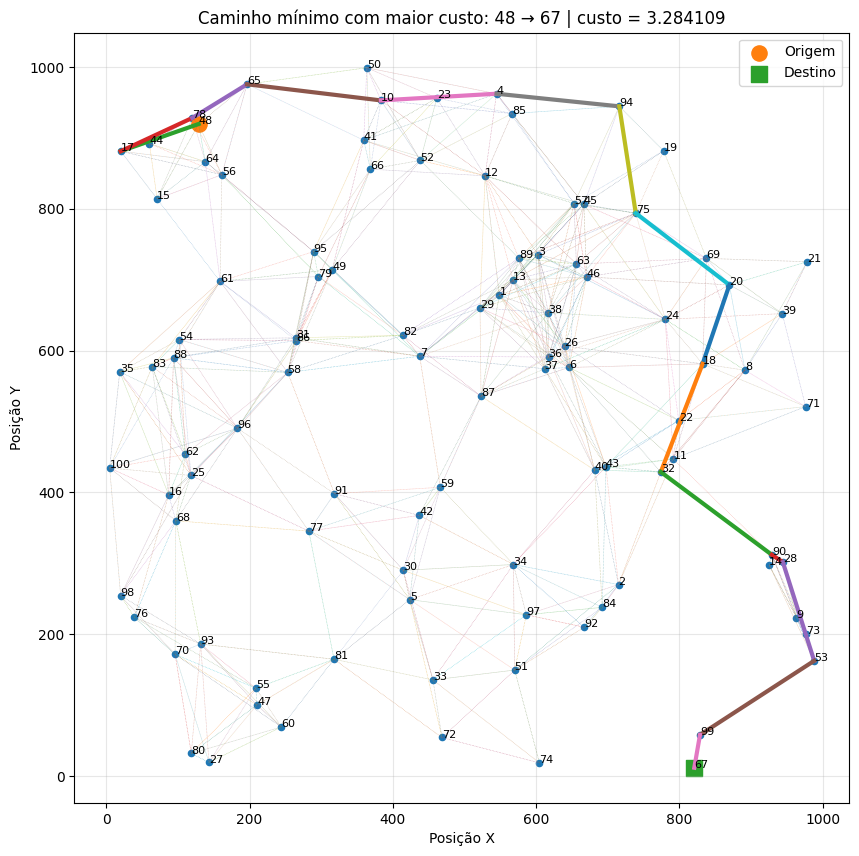

In [16]:
plt.figure(figsize=(10, 10))

# Grafo completo
for k in range(num_nos):
    for j in range(num_nos):
        if matriz[k, j] == 1:
            plt.plot([posX[k], posX[j]], [posY[k], posY[j]], linestyle=':', linewidth=0.4, alpha=0.4)

# Nós
plt.scatter(posX, posY, s=20)
for k in range(num_nos):
    plt.text(posX[k], posY[k], str(k + 1), fontsize=8)

# Caminho destacado
for a, b in zip(melhor_caminho[:-1], melhor_caminho[1:]):
    plt.plot([posX[a], posX[b]], [posY[a], posY[b]], linewidth=3)

plt.scatter(posX[melhor_origem], posY[melhor_origem], s=120, marker='o', label='Origem')
plt.scatter(posX[melhor_destino], posY[melhor_destino], s=120, marker='s', label='Destino')

plt.title(f'Caminho mínimo com maior custo: {melhor_origem + 1} → {melhor_destino + 1} | custo = {maior_custo:.6f}')
plt.xlabel('Posição X')
plt.ylabel('Posição Y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
